### **PART 02. EDA**


#### **01. Imports + load data**

In [2]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

ROOT_DIR = os.path.dirname(os.getcwd())
DATA_PROCESSED = os.path.join(ROOT_DIR, "data", "processed")

df = pd.read_csv(os.path.join(DATA_PROCESSED, "data_cleaned.csv"))
df["timestamp_local"] = pd.to_datetime(df["timestamp_local"])
df = df.set_index("timestamp_local").sort_index()

df.head()

,app_temp,azimuth,clouds,dewpt,dhi,dni,elev_angle,ghi,pod,precip,...,wind_dir,wind_gust_spd,wind_spd,aqi,co,no2,o3,pm10,pm25,so2
timestamp_local,,,,,,,,,,,,,,,,,,,,,
2022-01-13 00:00:00,17.0,239.9,100,15.9,0,0,-88.6,0,n,0.0,...,106,2.4,1.6,180.0,381.3,16.7,86.7,109.3,77.67,54.7
2022-01-13 01:00:00,16.8,95.5,100,16.3,0,0,-77.2,0,n,0.0,...,98,2.0,1.2,181.0,389.8,17.0,87.0,111.0,79.00,59.0
2022-01-13 02:00:00,16.4,96.7,91,16.0,0,0,-63.3,0,n,0.0,...,78,2.0,1.2,178.0,385.0,16.0,87.3,107.3,76.33,58.7
2022-01-13 03:00:00,16.1,99.2,83,15.6,0,0,-49.4,0,n,0.0,...,58,2.4,1.2,174.0,380.1,15.0,87.7,103.7,73.67,58.3
2022-01-13 04:00:00,15.7,102.2,75,15.2,0,0,-35.7,0,n,0.0,...,46,3.2,1.6,171.0,375.3,14.0,88.0,100.0,71.00,58.0


,missing_%
o3,0.21
so2,0.21
co,0.21
no2,0.21
vis,0.02
pm25,0.01
aqi,0.01
pm10,0.01


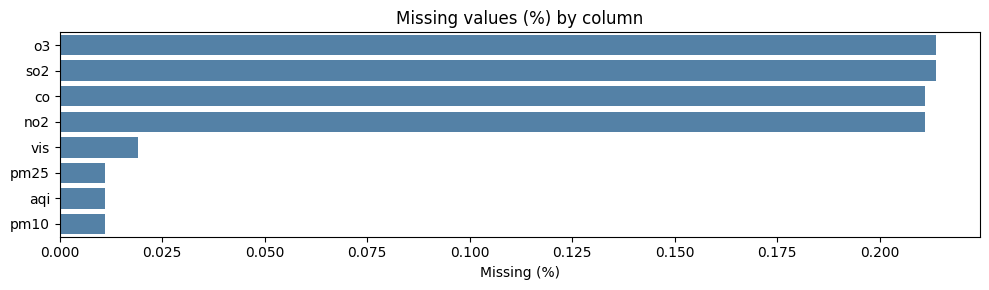

In [12]:
missing = (df.isna().mean() * 100).sort_values(ascending=False)
missing = missing[missing > 0]

# Pretty display (requires jinja2). If unavailable, fall back to plain display.
try:
    import jinja2  # noqa: F401
    display(missing.to_frame("missing_%").style.format("{:.2f}"))
except Exception:
    display(missing.to_frame("missing_%").round(2))

plt.figure(figsize=(10, max(3, 0.25 * len(missing))))
sns.barplot(x=missing.values, y=missing.index, color="steelblue")
plt.title("Missing values (%) by column")
plt.xlabel("Missing (%)")
plt.ylabel("")
plt.tight_layout()
plt.show()

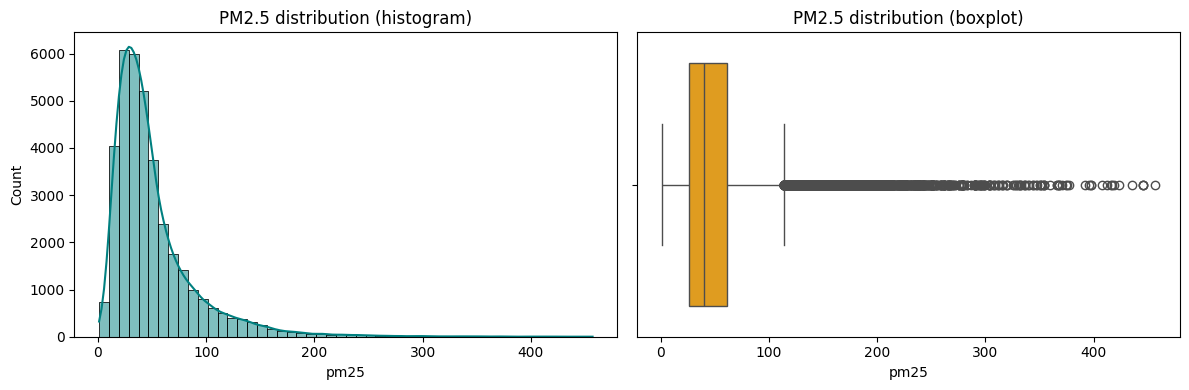

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
pm25,36476.0,50.817064,39.914228,1.0,8.0,13.6,26.0,39.8,61.0,129.0,206.0,457.0


In [7]:
target = "pm25"

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df[target].dropna(), bins=50, kde=True, ax=ax[0], color="teal")
ax[0].set_title("PM2.5 distribution (histogram)")

sns.boxplot(x=df[target], ax=ax[1], color="orange")
ax[1].set_title("PM2.5 distribution (boxplot)")

plt.tight_layout()
plt.show()

display(df[target].describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]).to_frame().T)

#### **04. Correlation heatmap pm25 vs temp, rh, wind_spd**

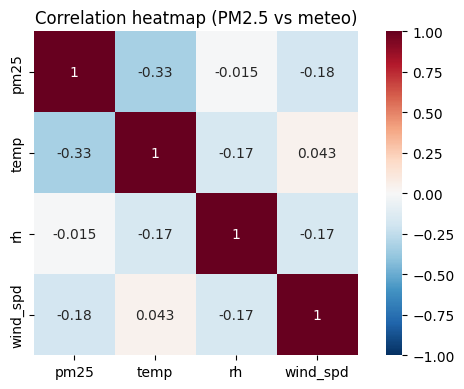

,pm25
pm25,1.000000
rh,-0.015274
wind_spd,-0.183812
temp,-0.331489


In [8]:
cols = ["pm25", "temp", "rh", "wind_spd"]
corr = df[cols].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap="RdBu_r", vmin=-1, vmax=1, square=True)
plt.title("Correlation heatmap (PM2.5 vs meteo)")
plt.tight_layout()
plt.show()

display(corr[["pm25"]].sort_values(by="pm25", ascending=False))

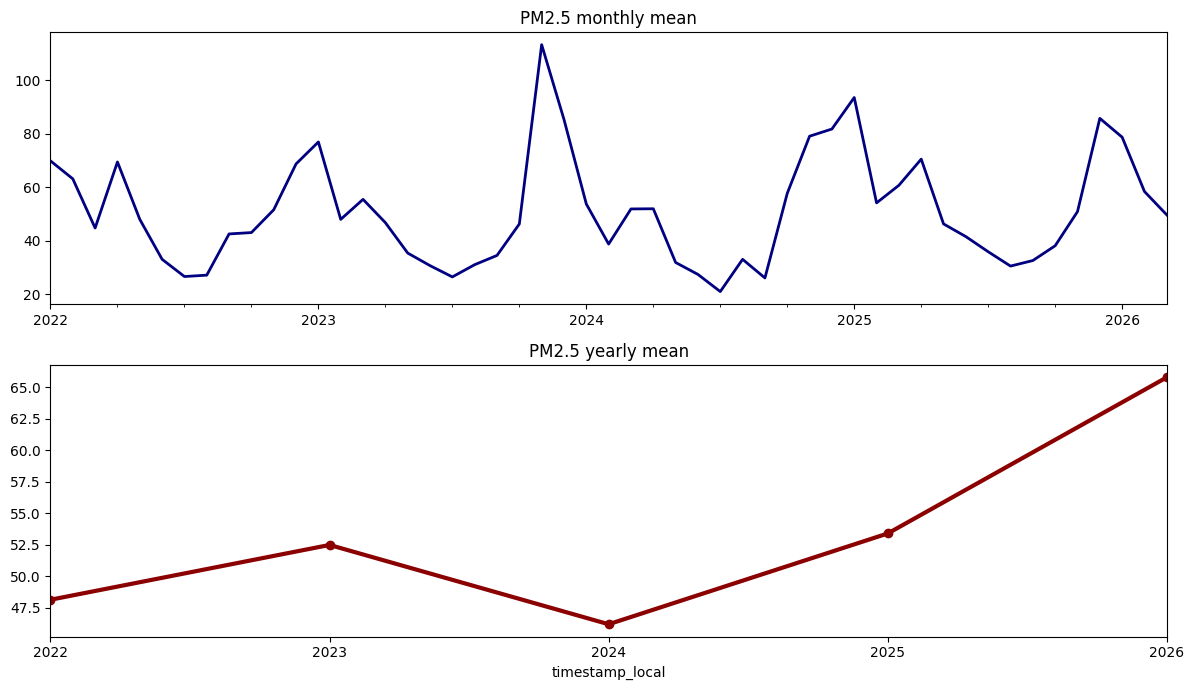

In [9]:
pm = df["pm25"].dropna()

monthly = pm.resample("MS").mean()
yearly  = pm.resample("YS").mean()

fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharey=False)

monthly.plot(ax=ax[0], color="navy", linewidth=2)
ax[0].set_title("PM2.5 monthly mean")
ax[0].set_xlabel("")

yearly.plot(ax=ax[1], color="darkred", linewidth=3, marker="o")
ax[1].set_title("PM2.5 yearly mean")

plt.tight_layout()
plt.show()

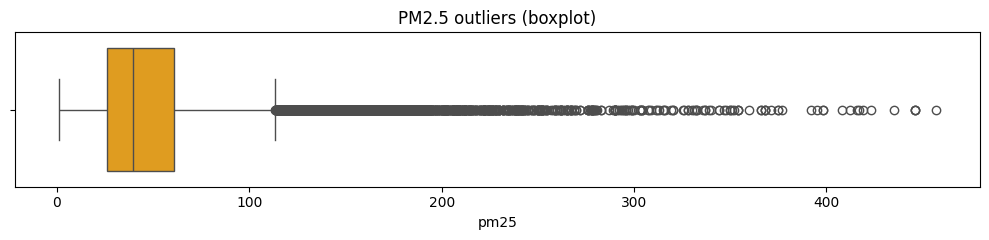

IQR bounds: [-26.50, 113.50]
Outliers: 2599/36476 (7.13%)


,pm25
timestamp_local,
2025-03-20 23:00:00,457.0
2023-11-19 20:00:00,446.0
2025-03-20 22:00:00,446.0
2023-11-19 22:00:00,446.0
2023-11-29 03:00:00,435.0
2023-11-19 21:00:00,423.0
2023-11-19 03:00:00,419.0
2024-02-07 19:00:00,417.0
2022-04-08 04:00:00,416.0


In [10]:
x = df["pm25"].dropna()

plt.figure(figsize=(10, 2.5))
sns.boxplot(x=x, color="orange")
plt.title("PM2.5 outliers (boxplot)")
plt.tight_layout()
plt.show()

q1, q3 = x.quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr

outlier_mask = (df["pm25"] < lower) | (df["pm25"] > upper)
n_outliers = int(outlier_mask.sum())
n_nonnull = int(df["pm25"].notna().sum())

print(f"IQR bounds: [{lower:.2f}, {upper:.2f}]")
print(f"Outliers: {n_outliers}/{n_nonnull} ({(n_outliers/n_nonnull)*100:.2f}%)")

display(df.loc[outlier_mask, ["pm25"]].sort_values(by="pm25", ascending=False).head(10))